# AI 对岗位与裁员风险影响分析

本 Notebook 根据 `ai_impact_jobs_layoff_risk_analysis_plan.md` 执行完整数据分析流程，覆盖数据质量检查、描述性分析、风险差异分析、特征工程、统计检验、预测建模、模型解释、聚类分群和业务洞察总结。

数据文件：`ai-impact-jobs-layoff-risk-dataset.csv`

目标变量：`Layoff_Risk`，包含 `Low`、`Medium`、`High` 三类。

说明：当前 Notebook 使用项目基础依赖中的 `pandas`、`numpy`、`matplotlib`、`seaborn`、`scipy` 和 `scikit-learn`。若环境额外安装了 `shap`，模型解释部分会自动尝试补充 SHAP 分析；否则使用特征重要性和 permutation importance 作为主要解释方法。

## 1. 环境与基础配置

In [1]:
import json
import math
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy.stats import chi2_contingency, kruskal, spearmanr
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
DATA_PATH = Path("ai-impact-jobs-layoff-risk-dataset.csv")
OUTPUT_DIR = Path("analysis_outputs")
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
for path in [OUTPUT_DIR, FIG_DIR, TABLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid", font="DejaVu Sans")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

def savefig(name: str):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    return path

print(f"Python: {sys.version.split()[0]}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

Python: 3.12.13
pandas: 3.0.3
numpy: 2.4.6


## 2. 读取数据与字段定义

In [2]:
df = pd.read_csv(DATA_PATH)

NUMERIC_COLS = [
    "Age",
    "Years_of_Experience",
    "Routine_Task_Percentage",
    "Creativity_Requirement",
    "Human_Interaction_Level",
    "Number_of_AI_Tools_Used",
    "AI_Usage_Hours_Per_Week",
    "Tasks_Automated_Percentage",
    "AI_Training_Hours",
]

CATEGORICAL_COLS = [
    "Education_Level",
    "Industry",
    "Job_Role",
    "Company_Size",
    "Job_Level",
    "AI_Adoption_Level",
]

TARGET_COL = "Layoff_Risk"
RISK_ORDER = ["Low", "Medium", "High"]

print(f"数据规模: {df.shape[0]:,} 行 x {df.shape[1]:,} 列")
display(df.head())
display(pd.DataFrame({"dtype": df.dtypes.astype(str), "n_unique": df.nunique()}).rename_axis("column"))

数据规模: 20,000 行 x 16 列


,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
0,59,Master's,6,Finance,Accountant,Medium,Entry,84,21,94,Medium,5,7,40,26,High
1,44,Master's,14,Manufacturing,Production Supervisor,Small,Entry,30,84,68,Low,2,2,14,9,Low
2,36,Bachelor's,7,Retail,Store Manager,Medium,Senior,12,86,71,Low,0,1,6,3,Low
3,27,Bachelor's,6,Finance,Auditor,Large,Entry,90,18,21,Medium,3,10,67,26,High
4,49,High School,12,Finance,Auditor,Small,Entry,49,52,72,Medium,5,13,26,19,Medium


,dtype,n_unique
column,,
Age,int64,40
Education_Level,str,4
Years_of_Experience,int64,27
Industry,str,8
Job_Role,str,24
Company_Size,str,3
Job_Level,str,3
Routine_Task_Percentage,int64,85
Creativity_Requirement,int64,101


## 3. 数据质量检查

本节检查字段类型、缺失值、重复记录、数值范围和类别一致性。

In [3]:
missing_summary = pd.DataFrame(
    {
        "missing_count": df.isna().sum(),
        "missing_rate": df.isna().mean(),
    }
)

duplicate_count = df.duplicated().sum()

range_checks = {
    "Age outside 21-60": (~df["Age"].between(21, 60)).sum(),
    "Years_of_Experience < 0": (df["Years_of_Experience"] < 0).sum(),
    "Years_of_Experience > Age - 18": (df["Years_of_Experience"] > (df["Age"] - 18)).sum(),
    "Routine_Task_Percentage outside 0-100": (~df["Routine_Task_Percentage"].between(0, 100)).sum(),
    "Tasks_Automated_Percentage outside 0-100": (~df["Tasks_Automated_Percentage"].between(0, 100)).sum(),
    "Creativity_Requirement outside 0-100": (~df["Creativity_Requirement"].between(0, 100)).sum(),
    "Human_Interaction_Level outside 0-100": (~df["Human_Interaction_Level"].between(0, 100)).sum(),
    "AI_Usage_Hours_Per_Week > 80": (df["AI_Usage_Hours_Per_Week"] > 80).sum(),
    "AI_Training_Hours > 200": (df["AI_Training_Hours"] > 200).sum(),
}

expected_categories = {
    "Education_Level": {"High School", "Bachelor's", "Master's", "PhD"},
    "Company_Size": {"Small", "Medium", "Large"},
    "Job_Level": {"Entry", "Mid", "Senior"},
    "AI_Adoption_Level": {"Low", "Medium", "High"},
    "Layoff_Risk": {"Low", "Medium", "High"},
}

category_checks = []
for col, expected in expected_categories.items():
    actual = set(df[col].dropna().unique())
    category_checks.append(
        {
            "column": col,
            "unexpected_values": sorted(actual - expected),
            "missing_expected_values": sorted(expected - actual),
            "actual_values": sorted(actual),
        }
    )

quality_summary = pd.DataFrame(
    {
        "item": [
            "rows",
            "columns",
            "duplicate_records",
            "columns_with_missing_values",
            "total_missing_values",
        ],
        "value": [
            df.shape[0],
            df.shape[1],
            duplicate_count,
            int((df.isna().sum() > 0).sum()),
            int(df.isna().sum().sum()),
        ],
    }
)

display(quality_summary)
display(missing_summary)
display(pd.DataFrame(range_checks.items(), columns=["check", "violations"]))
display(pd.DataFrame(category_checks))

missing_summary.to_csv(TABLE_DIR / "missing_summary.csv")
pd.DataFrame(range_checks.items(), columns=["check", "violations"]).to_csv(
    TABLE_DIR / "range_checks.csv", index=False
)

,item,value
0,rows,20000
1,columns,16
2,duplicate_records,0
3,columns_with_missing_values,0
4,total_missing_values,0


,missing_count,missing_rate
Age,0,0.000
Education_Level,0,0.000
Years_of_Experience,0,0.000
Industry,0,0.000
Job_Role,0,0.000
Company_Size,0,0.000
Job_Level,0,0.000
Routine_Task_Percentage,0,0.000
Creativity_Requirement,0,0.000
Human_Interaction_Level,0,0.000


,check,violations
0,Age outside 21-60,0
1,Years_of_Experience < 0,0
2,Years_of_Experience > Age - 18,0
3,Routine_Task_Percentage outside 0-100,0
4,Tasks_Automated_Percentage outside 0-100,0
5,Creativity_Requirement outside 0-100,0
6,Human_Interaction_Level outside 0-100,0
7,AI_Usage_Hours_Per_Week > 80,0
8,AI_Training_Hours > 200,0


,column,unexpected_values,missing_expected_values,actual_values
0,Education_Level,[],[],"[Bachelor's, High School, Master's, PhD]"
1,Company_Size,[],[],"[Large, Medium, Small]"
2,Job_Level,[],[],"[Entry, Mid, Senior]"
3,AI_Adoption_Level,[],[],"[High, Low, Medium]"
4,Layoff_Risk,[],[],"[High, Low, Medium]"


**数据质量结论**

若上表中的缺失值、范围异常和类别异常均为 0，则该数据集可直接进入后续分析。`Years_of_Experience > Age - 18` 用于检查经验年限是否与年龄存在明显逻辑冲突。

## 4. 描述性分析

In [4]:
numeric_summary = df[NUMERIC_COLS].describe().T
numeric_summary["missing"] = df[NUMERIC_COLS].isna().sum()
display(numeric_summary)
numeric_summary.to_csv(TABLE_DIR / "numeric_summary.csv")

def category_distribution(data: pd.DataFrame, col: str) -> pd.DataFrame:
    counts = data[col].value_counts(dropna=False)
    pct = data[col].value_counts(normalize=True, dropna=False)
    return pd.DataFrame({"count": counts, "pct": pct}).reset_index(names=col)

for col in CATEGORICAL_COLS + [TARGET_COL]:
    dist = category_distribution(df, col)
    display(Markdown(f"### {col}"))
    display(dist)
    dist.to_csv(TABLE_DIR / f"distribution_{col}.csv", index=False)

,count,mean,std,min,25%,50%,75%,max,missing
Age,"20,000.000",40.361,11.526,21.000,30.000,40.000,50.000,60.000,0
Years_of_Experience,"20,000.000",7.266,4.721,0.000,4.000,7.000,11.000,32.000,0
Routine_Task_Percentage,"20,000.000",51.886,24.438,10.000,31.000,52.000,73.000,94.000,0
Creativity_Requirement,"20,000.000",47.787,26.100,0.000,27.000,48.000,69.000,100.000,0
Human_Interaction_Level,"20,000.000",60.055,22.268,20.000,41.000,62.000,79.000,99.000,0
Number_of_AI_Tools_Used,"20,000.000",2.460,2.097,0.000,1.000,2.000,4.000,10.000,0
AI_Usage_Hours_Per_Week,"20,000.000",6.774,6.086,0.000,2.000,5.000,10.000,30.000,0
Tasks_Automated_Percentage,"20,000.000",37.229,19.995,4.000,21.000,35.000,51.000,93.000,0
AI_Training_Hours,"20,000.000",12.621,13.553,0.000,4.000,8.000,18.000,79.000,0


### Education_Level

,Education_Level,count,pct
0,Bachelor's,9967,0.498
1,Master's,5426,0.271
2,High School,3558,0.178
3,PhD,1049,0.052


### Industry

,Industry,count,pct
0,Telecom,2582,0.129
1,Healthcare,2561,0.128
2,Finance,2513,0.126
3,Logistics,2488,0.124
4,IT,2483,0.124
5,Retail,2467,0.123
6,Manufacturing,2457,0.123
7,Education,2449,0.122


...

,Job_Level,count,pct
0,Entry,9016,0.451
1,Mid,7940,0.397
2,Senior,3044,0.152


### AI_Adoption_Level

,AI_Adoption_Level,count,pct
0,Low,10539,0.527
1,Medium,8046,0.402
2,High,1415,0.071


### Layoff_Risk

,Layoff_Risk,count,pct
0,High,6797,0.340
1,Low,6602,0.330
2,Medium,6601,0.330


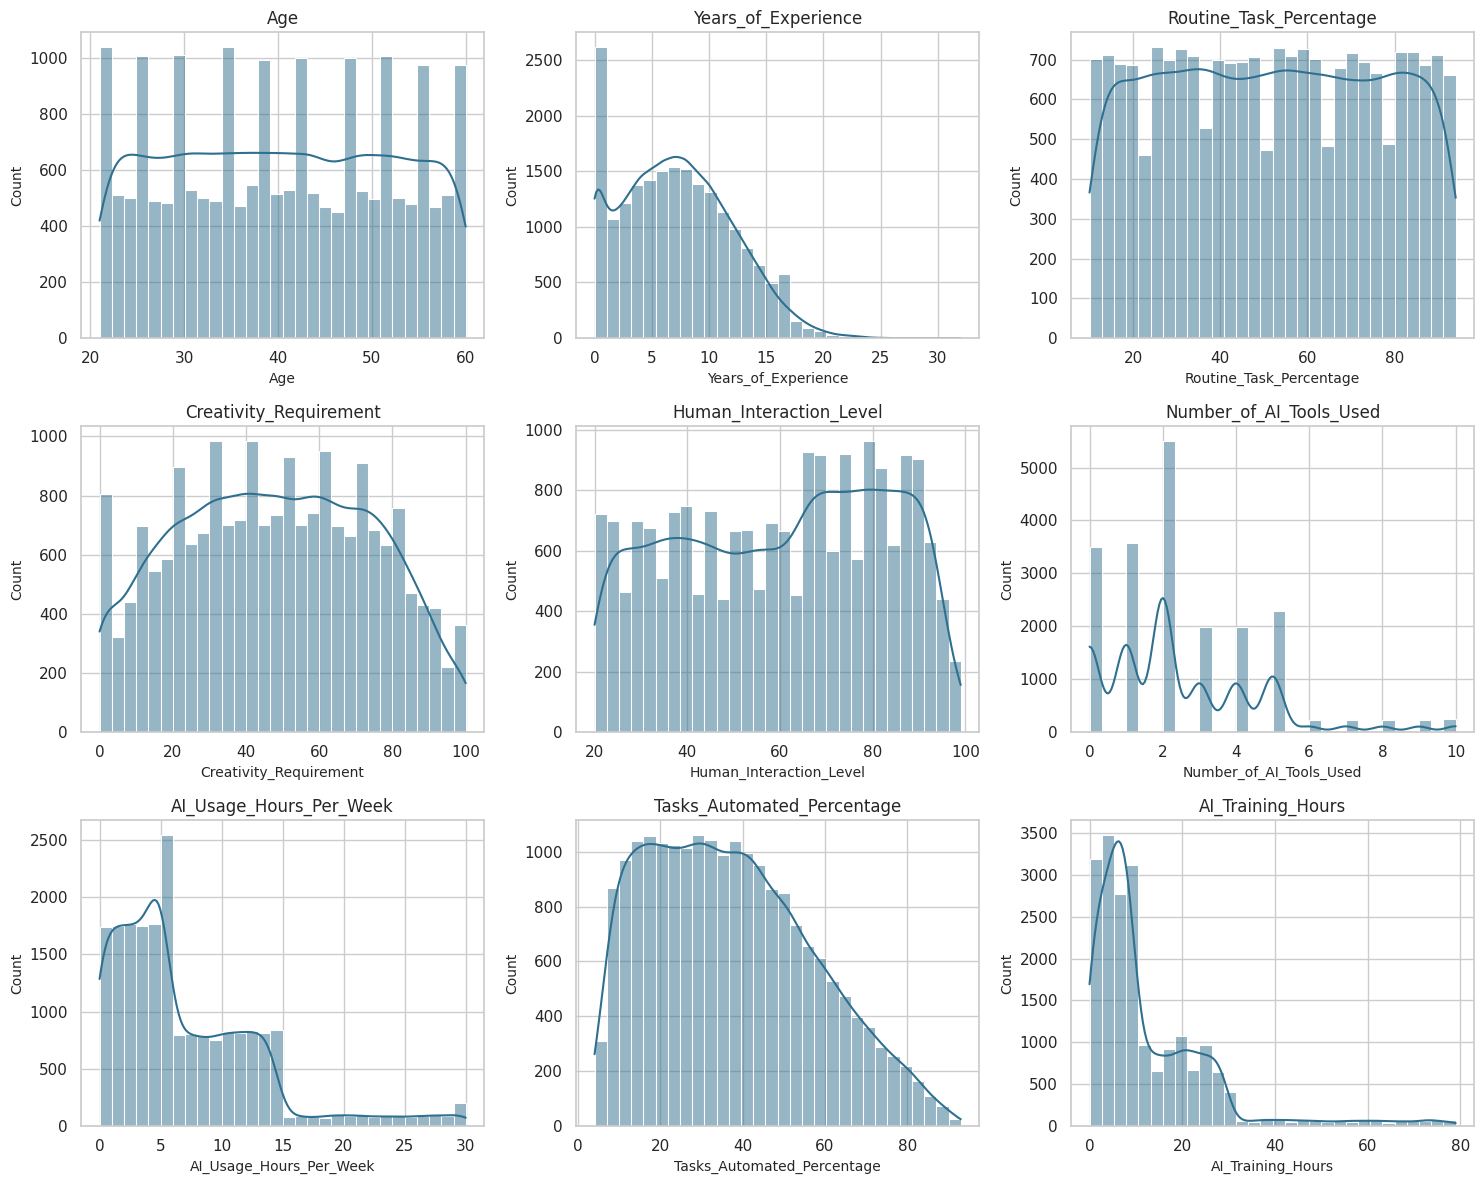

PosixPath('analysis_outputs/figures/numeric_distributions.png')

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()
for ax, col in zip(axes, NUMERIC_COLS):
    sns.histplot(df[col], bins=30, kde=True, ax=ax, color="#2f6f8f")
    ax.set_title(col)
savefig("numeric_distributions.png")

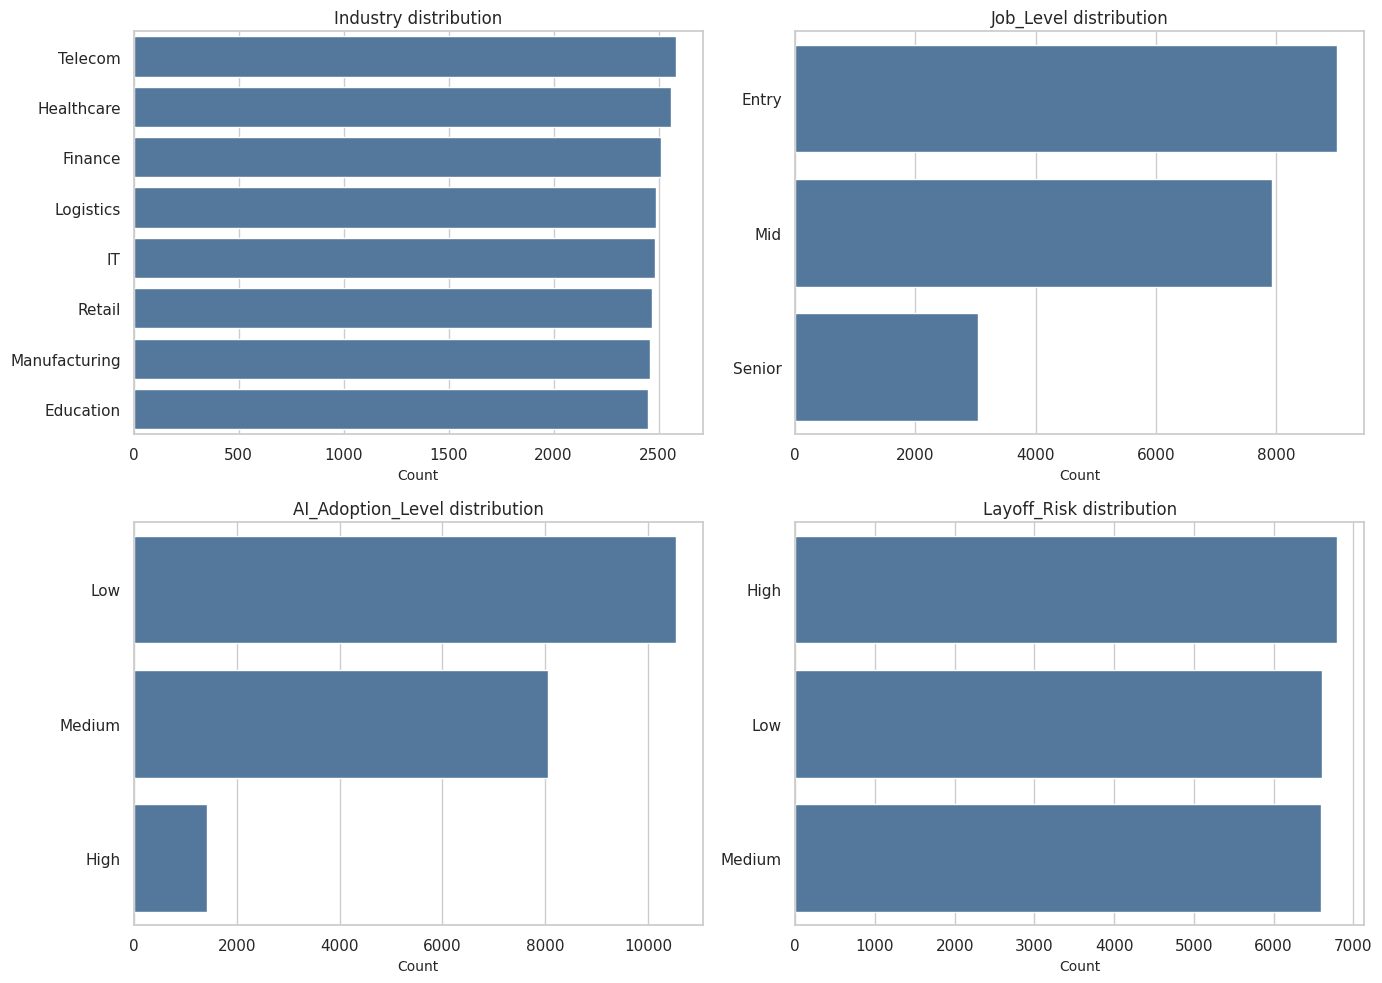

PosixPath('analysis_outputs/figures/key_category_distributions.png')

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
plot_cols = ["Industry", "Job_Level", "AI_Adoption_Level", "Layoff_Risk"]
for ax, col in zip(axes, plot_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, color="#4878a8")
    ax.set_title(f"{col} distribution")
    ax.set_xlabel("Count")
    ax.set_ylabel("")
savefig("key_category_distributions.png")

,count,pct
Layoff_Risk,,
Low,6602,0.330
Medium,6601,0.330
High,6797,0.340


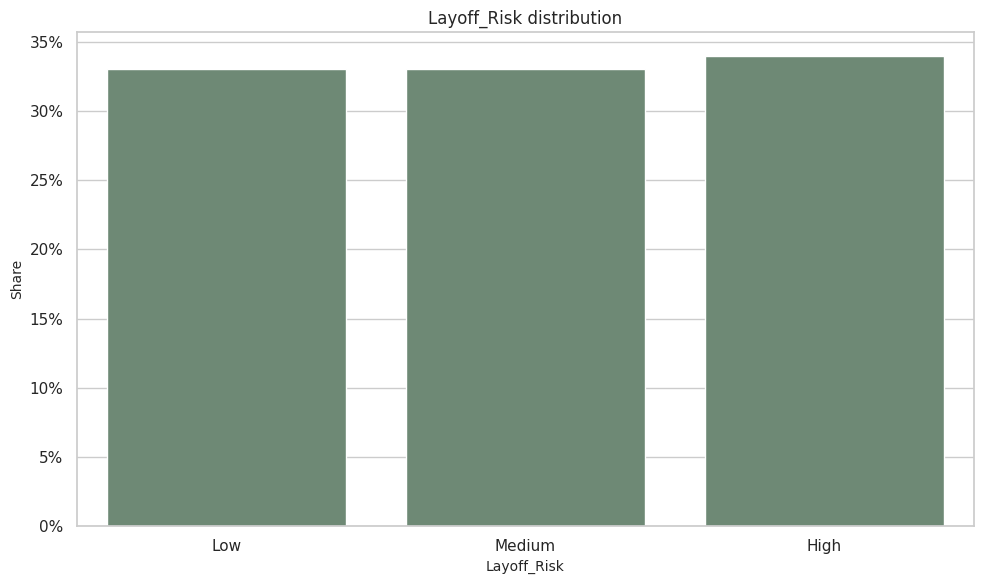

PosixPath('analysis_outputs/figures/target_distribution.png')

In [7]:
target_dist = (
    df[TARGET_COL]
    .value_counts()
    .reindex(RISK_ORDER)
    .to_frame("count")
    .assign(pct=lambda x: x["count"] / x["count"].sum())
)
display(target_dist)

sns.barplot(x=target_dist.index, y=target_dist["pct"], color="#6a8d73")
plt.gca().yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.title("Layoff_Risk distribution")
plt.xlabel("Layoff_Risk")
plt.ylabel("Share")
savefig("target_distribution.png")

## 5. 单变量与裁员风险关系分析

In [8]:
def risk_distribution(data: pd.DataFrame, col: str) -> pd.DataFrame:
    tab = pd.crosstab(data[col], data[TARGET_COL], normalize="index")
    tab = tab.reindex(columns=RISK_ORDER)
    count = data[col].value_counts().rename("n")
    result = tab.join(count)
    result["High_Rate"] = result["High"]
    return result.sort_values("High_Rate", ascending=False)

category_risk_tables = {}
for col in CATEGORICAL_COLS:
    table = risk_distribution(df, col)
    category_risk_tables[col] = table
    display(Markdown(f"### {col} 与裁员风险"))
    display(table)
    table.to_csv(TABLE_DIR / f"risk_distribution_by_{col}.csv")

### Education_Level 与裁员风险

,Low,Medium,High,n,High_Rate
Education_Level,,,,,
High School,0.220,0.325,0.456,3558,0.456
Bachelor's,0.312,0.337,0.351,9967,0.351
Master's,0.403,0.326,0.271,5426,0.271
PhD,0.497,0.302,0.201,1049,0.201


### Industry 与裁员风险

,Low,Medium,High,n,High_Rate
Industry,,,,,
Manufacturing,0.195,0.323,0.482,2457,0.482
Logistics,0.250,0.335,0.415,2488,0.415
Retail,0.251,0.342,0.407,2467,0.407
Finance,0.273,0.350,0.377,2513,0.377
Telecom,0.329,0.319,0.352,2582,0.352
IT,0.382,0.339,0.280,2483,0.280
Healthcare,0.474,0.318,0.208,2561,0.208
Education,0.484,0.315,0.201,2449,0.201


### Job_Role 与裁员风险

...

,Low,Medium,High,n,High_Rate
Company_Size,,,,,
Medium,0.324,0.327,0.349,8964,0.349
Small,0.331,0.336,0.333,6066,0.333
Large,0.340,0.328,0.332,4970,0.332


### Job_Level 与裁员风险

,Low,Medium,High,n,High_Rate
Job_Level,,,,,
Entry,0.228,0.327,0.445,9016,0.445
Mid,0.352,0.342,0.307,7940,0.307
Senior,0.577,0.308,0.115,3044,0.115


### AI_Adoption_Level 与裁员风险

,Low,Medium,High,n,High_Rate
AI_Adoption_Level,,,,,
High,0.012,0.180,0.808,1415,0.808
Medium,0.083,0.336,0.582,8046,0.582
Low,0.562,0.346,0.092,10539,0.092


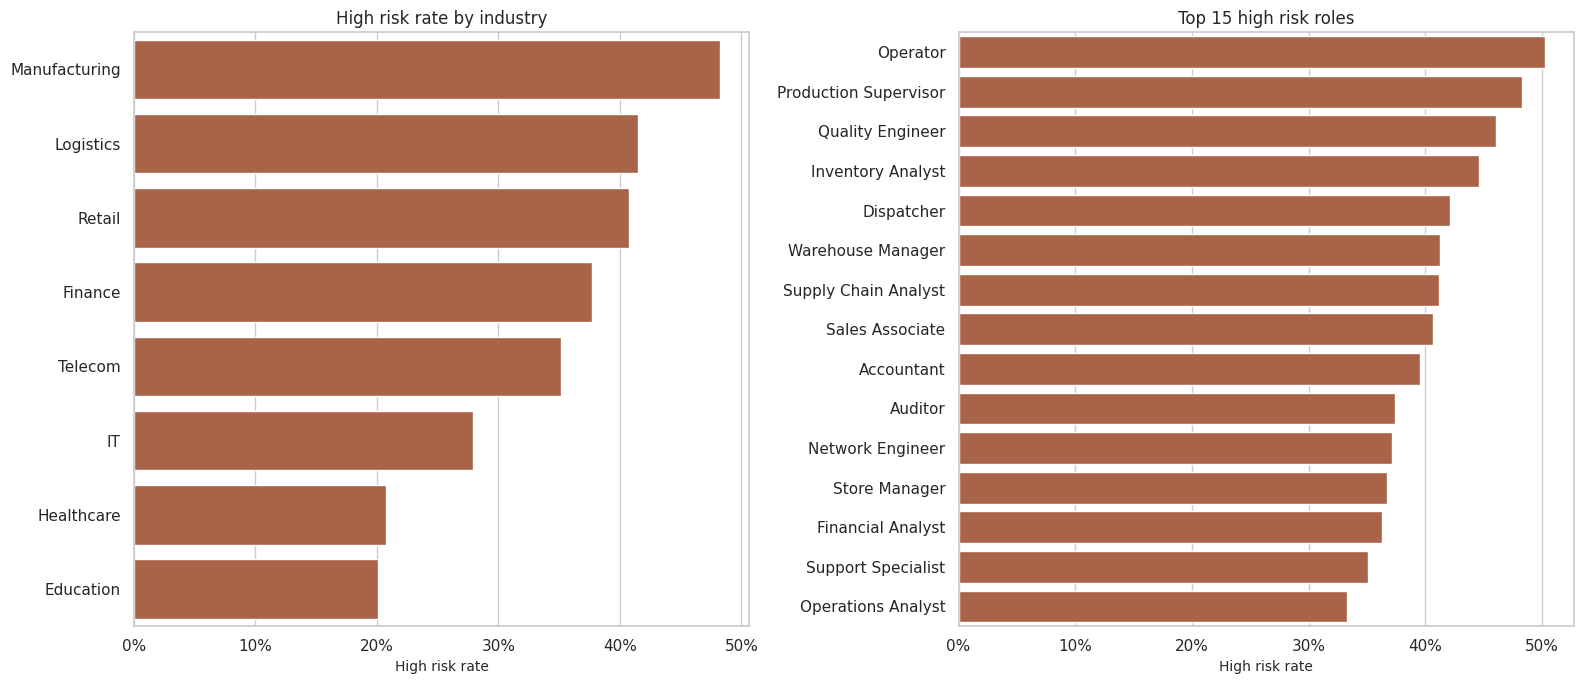

In [9]:
high_risk_by_industry = risk_distribution(df, "Industry")
high_risk_by_role = risk_distribution(df, "Job_Role")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(
    data=high_risk_by_industry.reset_index(),
    y="Industry",
    x="High_Rate",
    ax=axes[0],
    color="#b85c38",
)
axes[0].xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
axes[0].set_title("High risk rate by industry")
axes[0].set_xlabel("High risk rate")
axes[0].set_ylabel("")

role_plot = high_risk_by_role.head(15).reset_index()
sns.barplot(
    data=role_plot,
    y="Job_Role",
    x="High_Rate",
    ax=axes[1],
    color="#b85c38",
)
axes[1].xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
axes[1].set_title("Top 15 high risk roles")
axes[1].set_xlabel("High risk rate")
axes[1].set_ylabel("")
savefig("high_risk_rates_industry_role.png")

high_risk_by_industry.to_csv(TABLE_DIR / "high_risk_by_industry.csv")
high_risk_by_role.to_csv(TABLE_DIR / "high_risk_by_job_role.csv")

Age               Years_of_Experience               \
              mean median    std                mean median   std   
Layoff_Risk                                                         
High        39.863 40.000 11.808               6.694  6.000 4.771   
Low         40.901 41.000 11.341               7.854  8.000 4.679   
Medium      40.334 40.000 11.394               7.265  7.000 4.638   

            Routine_Task_Percentage               Creativity_Requirement  \
                               mean median    std                   mean   
Layoff_Risk                                                                
High                         75.173 77.000 13.414                 23.844   
Low                          28.540 26.000 14.363                 71.927   
Medium                       51.256 50.000 17.719                 48.296   

                          Human_Interaction_Level                \
            median    std                    mean median    std   
Layoff_Risk                                                       
High        22.000 15.568                  55.924 56.000 22.116   
Low         74.000 16.643                  64.628 69.000 21.597   
Medium      49.000 19.082                  59.735 62.000 22.221   

            Number_of_AI_Tools_Used              AI_Usage_Hours_Per_Week  \
                               mean median   std                    mean   
Layoff_Risk                                                                
High                          3.813  4.000 2.211                  10.768   
Low                           1.254  1.000 1.168                   3.273   
Medium                        2.274  2.000 1.887                   6.163   

                         Tasks_Automated_Percentage                \
            median   std                       mean median    std   
Layoff_Risk                                                         
High        10.000 6.679                     55.957 55.000 15.023   
Low          3.000 3.000                     19.451 17.000 10.495   
Medium       5.000 5.315                     35.725 34.000 13.758   

            AI_Training_Hours                
                         mean median    std  
Layoff_Risk                                  
High                   20.245 17.000 16.407  
Low                     5.971  5.000  5.999  
Medium                 11.423  8.000 11.741

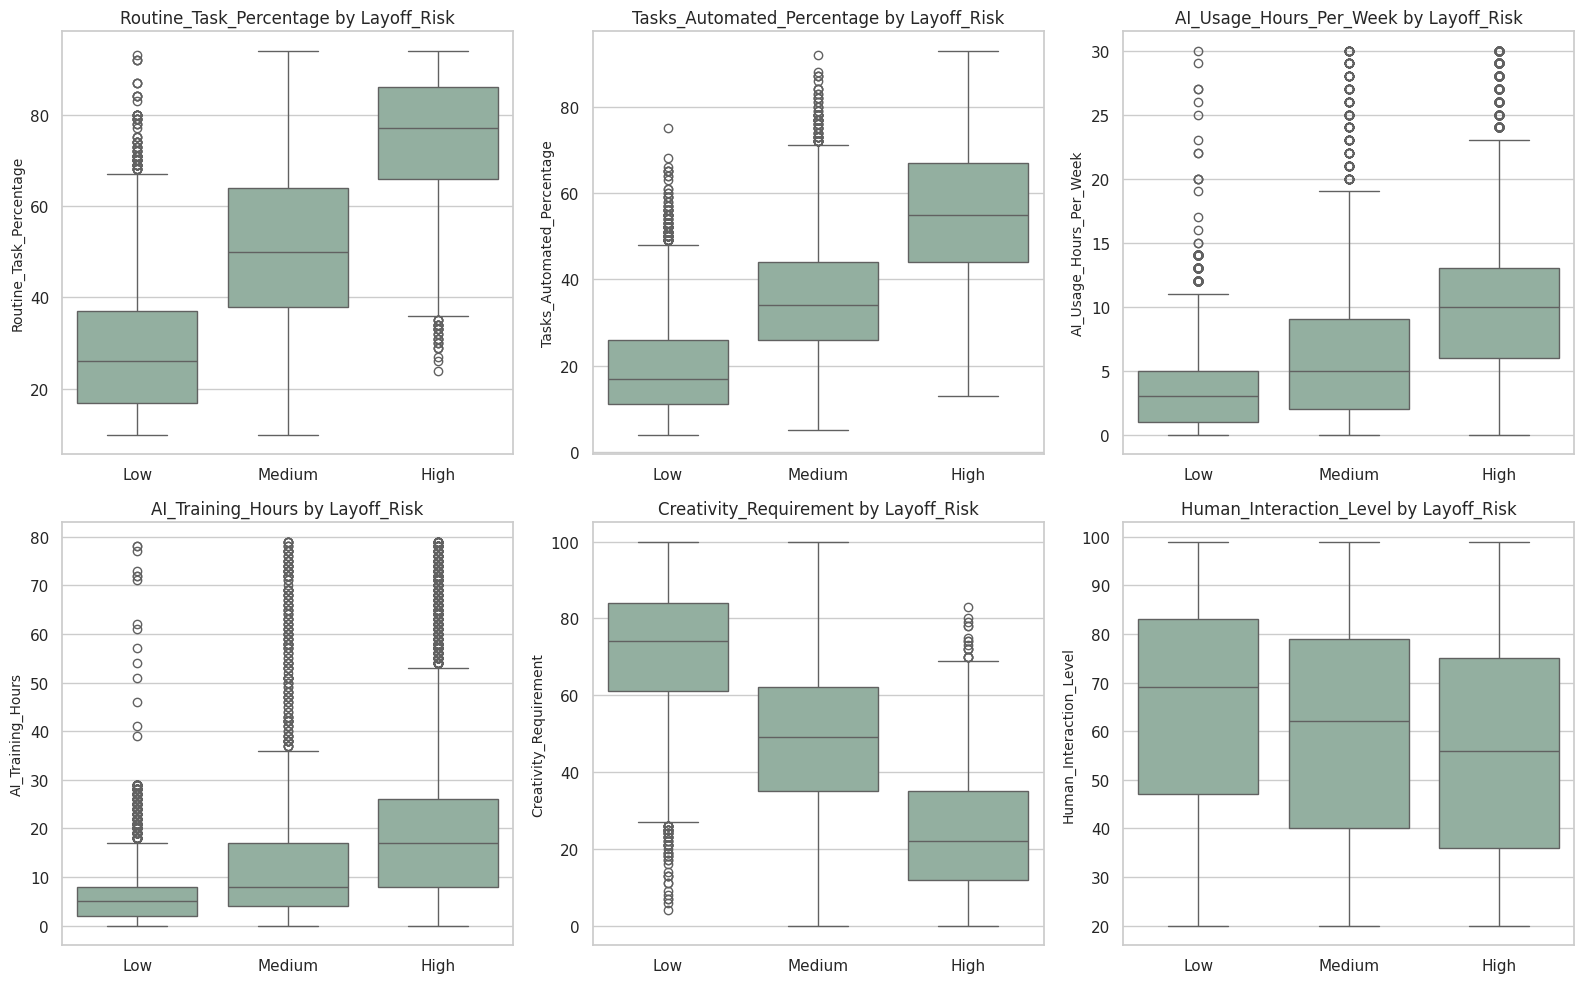

PosixPath('analysis_outputs/figures/numeric_features_by_risk_boxplots.png')

In [10]:
numeric_by_risk = df.groupby(TARGET_COL)[NUMERIC_COLS].agg(["mean", "median", "std"])
display(numeric_by_risk)
numeric_by_risk.to_csv(TABLE_DIR / "numeric_by_layoff_risk.csv")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()
box_cols = [
    "Routine_Task_Percentage",
    "Tasks_Automated_Percentage",
    "AI_Usage_Hours_Per_Week",
    "AI_Training_Hours",
    "Creativity_Requirement",
    "Human_Interaction_Level",
]
for ax, col in zip(axes, box_cols):
    sns.boxplot(data=df, x=TARGET_COL, y=col, order=RISK_ORDER, ax=ax, color="#8fb3a0")
    ax.set_title(f"{col} by Layoff_Risk")
    ax.set_xlabel("")
savefig("numeric_features_by_risk_boxplots.png")

## 6. 多变量交叉分析

n  high_rate
Industry      Job_Role                             
Manufacturing Operator               858      0.502
              Production Supervisor  806      0.483
              Quality Engineer       793      0.460
Retail        Inventory Analyst      857      0.446
Logistics     Dispatcher             788      0.421
              Warehouse Manager      843      0.413
              Supply Chain Analyst   857      0.412
Retail        Sales Associate        807      0.406
Finance       Accountant             821      0.396
              Auditor                813      0.374
Telecom       Network Engineer       862      0.371
Retail        Store Manager          803      0.367
Finance       Financial Analyst      879      0.363
Telecom       Support Specialist     873      0.351
              Operations Analyst     847      0.333
IT            Data Analyst           849      0.283
              Software Engineer      829      0.281
              ML Engineer            805      0.275
Healthcare    Medical Assistant      889      0.245
Education     Academic Coordinator   819      0.228

,Job_Level,AI_Adoption_Level,n,high_rate
0,Entry,High,658,0.935
3,Mid,High,564,0.789
6,Senior,High,193,0.430
1,Entry,Low,4734,0.150
4,Mid,Low,4215,0.060
7,Senior,Low,1590,0.007
2,Entry,Medium,3624,0.742
5,Mid,Medium,3161,0.550
8,Senior,Medium,1261,0.202


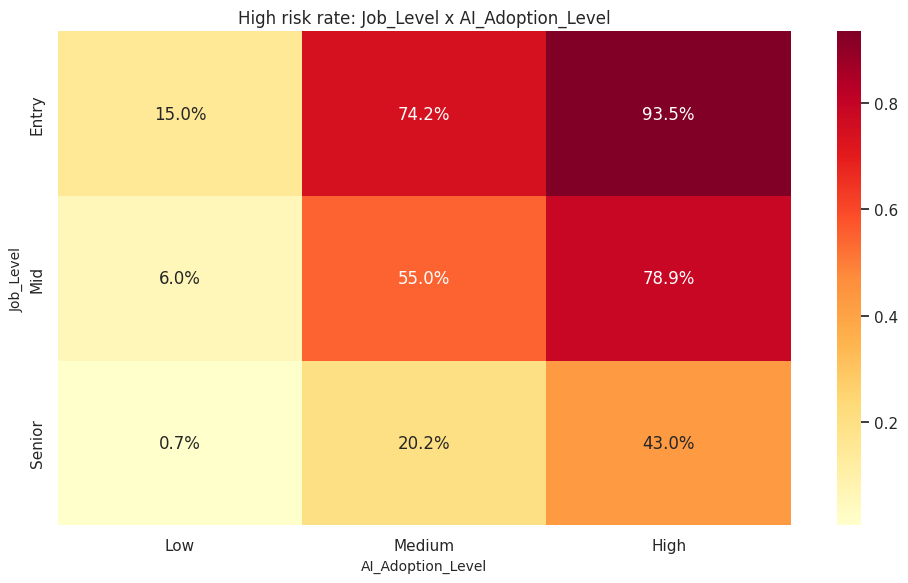

PosixPath('analysis_outputs/figures/job_level_ai_adoption_high_risk_heatmap.png')

In [11]:
industry_role_risk = (
    df.assign(Is_High=lambda x: x[TARGET_COL].eq("High"))
    .groupby(["Industry", "Job_Role"], observed=True)
    .agg(n=(TARGET_COL, "size"), high_rate=("Is_High", "mean"))
    .query("n >= 50")
    .sort_values("high_rate", ascending=False)
)
display(industry_role_risk.head(20))
industry_role_risk.to_csv(TABLE_DIR / "industry_role_high_risk_ranking.csv")

job_ai_risk = (
    df.assign(Is_High=lambda x: x[TARGET_COL].eq("High"))
    .groupby(["Job_Level", "AI_Adoption_Level"], observed=True)
    .agg(n=(TARGET_COL, "size"), high_rate=("Is_High", "mean"))
    .reset_index()
    .sort_values(["AI_Adoption_Level", "Job_Level"])
)
display(job_ai_risk)
job_ai_risk.to_csv(TABLE_DIR / "job_level_ai_adoption_high_risk.csv", index=False)

pivot_job_ai = job_ai_risk.pivot(index="Job_Level", columns="AI_Adoption_Level", values="high_rate")
pivot_job_ai = pivot_job_ai.reindex(index=["Entry", "Mid", "Senior"], columns=["Low", "Medium", "High"])
sns.heatmap(pivot_job_ai, annot=True, fmt=".1%", cmap="YlOrRd")
plt.title("High risk rate: Job_Level x AI_Adoption_Level")
savefig("job_level_ai_adoption_high_risk_heatmap.png")

,Routine_Band,Automation_Band,n,high_rate
0,0-25,0-25,3751,0.000
1,26-50,0-25,2781,0.020
2,26-50,26-50,3144,0.093
3,51-75,0-25,101,0.089
4,51-75,26-50,3851,0.375
5,51-75,51-75,1943,0.662
6,76-100,26-50,1183,0.721
7,76-100,51-75,2400,0.855
8,76-100,76-100,846,0.949


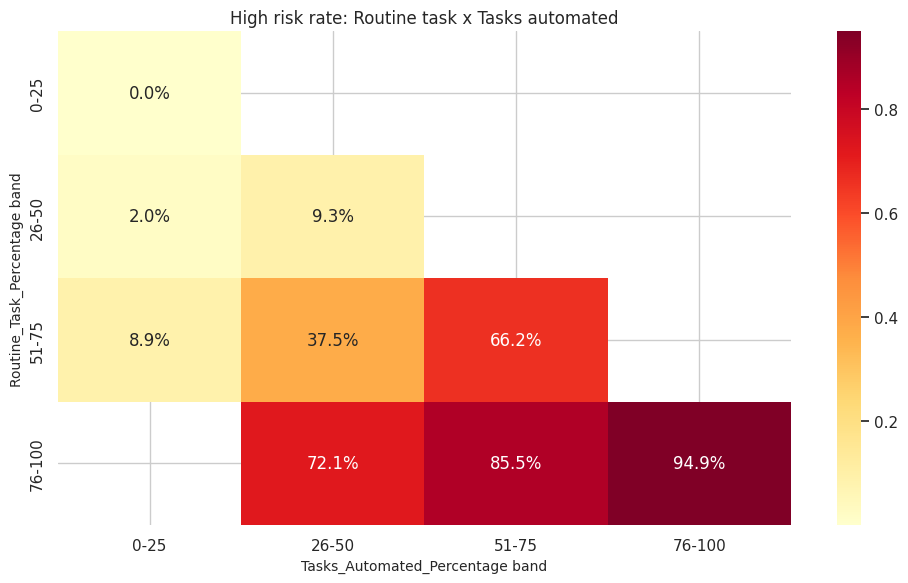

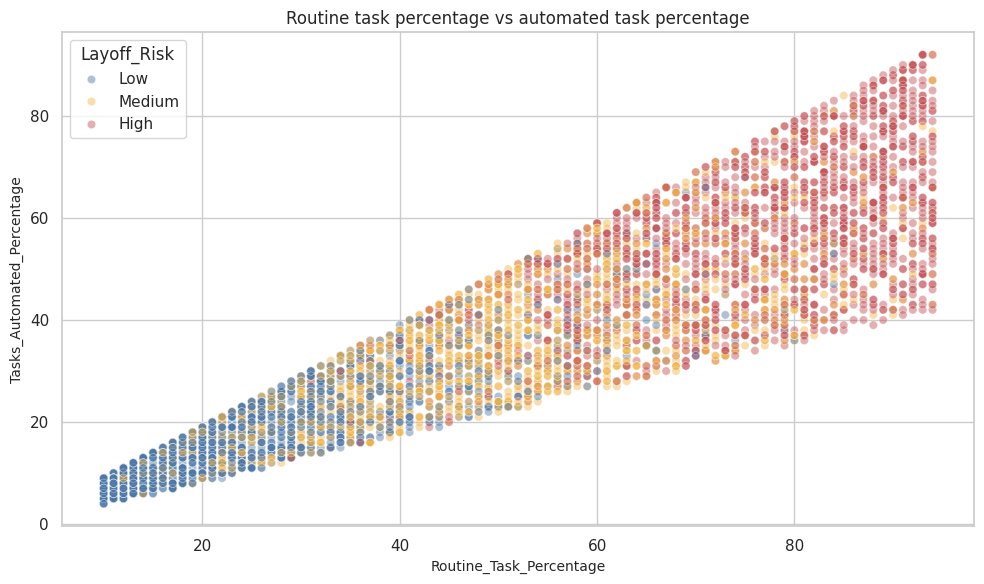

PosixPath('analysis_outputs/figures/routine_vs_automation_scatter.png')

In [12]:
binned = df.copy()
binned["Routine_Band"] = pd.cut(
    binned["Routine_Task_Percentage"],
    bins=[-0.1, 25, 50, 75, 100],
    labels=["0-25", "26-50", "51-75", "76-100"],
)
binned["Automation_Band"] = pd.cut(
    binned["Tasks_Automated_Percentage"],
    bins=[-0.1, 25, 50, 75, 100],
    labels=["0-25", "26-50", "51-75", "76-100"],
)
routine_auto_risk = (
    binned.assign(Is_High=lambda x: x[TARGET_COL].eq("High"))
    .groupby(["Routine_Band", "Automation_Band"], observed=True)
    .agg(n=(TARGET_COL, "size"), high_rate=("Is_High", "mean"))
    .reset_index()
)
display(routine_auto_risk)
routine_auto_risk.to_csv(TABLE_DIR / "routine_automation_high_risk.csv", index=False)

pivot_routine_auto = routine_auto_risk.pivot(
    index="Routine_Band", columns="Automation_Band", values="high_rate"
)
sns.heatmap(pivot_routine_auto, annot=True, fmt=".1%", cmap="YlOrRd")
plt.title("High risk rate: Routine task x Tasks automated")
plt.xlabel("Tasks_Automated_Percentage band")
plt.ylabel("Routine_Task_Percentage band")
savefig("routine_automation_high_risk_heatmap.png")

sns.scatterplot(
    data=df.sample(min(5000, len(df)), random_state=RANDOM_STATE),
    x="Routine_Task_Percentage",
    y="Tasks_Automated_Percentage",
    hue=TARGET_COL,
    hue_order=RISK_ORDER,
    alpha=0.45,
    palette=["#4c78a8", "#f2b447", "#c44e52"],
)
plt.title("Routine task percentage vs automated task percentage")
savefig("routine_vs_automation_scatter.png")

,Creativity_Band,Interaction_Band,n,high_rate
0,Low,Low,1105,0.866
1,Low,Medium,2615,0.796
2,Low,High,2873,0.670
3,Medium,Low,1275,0.355
4,Medium,Medium,3055,0.264
5,Medium,High,3528,0.154
6,High,Low,877,0.013
7,High,Medium,2178,0.007
8,High,High,2494,0.002


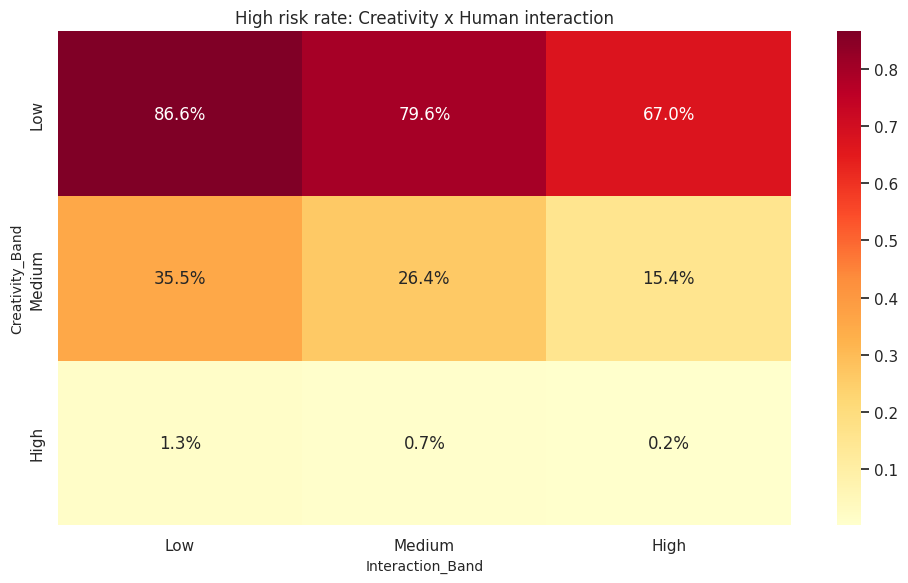

PosixPath('analysis_outputs/figures/creativity_interaction_high_risk_heatmap.png')

In [13]:
binned["Creativity_Band"] = pd.cut(
    binned["Creativity_Requirement"],
    bins=[-0.1, 33, 66, 100],
    labels=["Low", "Medium", "High"],
)
binned["Interaction_Band"] = pd.cut(
    binned["Human_Interaction_Level"],
    bins=[-0.1, 33, 66, 100],
    labels=["Low", "Medium", "High"],
)
creative_interaction_risk = (
    binned.assign(Is_High=lambda x: x[TARGET_COL].eq("High"))
    .groupby(["Creativity_Band", "Interaction_Band"], observed=True)
    .agg(n=(TARGET_COL, "size"), high_rate=("Is_High", "mean"))
    .reset_index()
)
display(creative_interaction_risk)
creative_interaction_risk.to_csv(TABLE_DIR / "creativity_interaction_high_risk.csv", index=False)

pivot_creative_interaction = creative_interaction_risk.pivot(
    index="Creativity_Band", columns="Interaction_Band", values="high_rate"
)
sns.heatmap(pivot_creative_interaction, annot=True, fmt=".1%", cmap="YlOrRd")
plt.title("High risk rate: Creativity x Human interaction")
savefig("creativity_interaction_high_risk_heatmap.png")

## 7. 特征工程

按分析计划构造自动化暴露指数、人类能力保护指数、AI 使用强度指数、经验分组、年龄分组和二分类风险目标。

In [14]:
df_fe = df.copy()

ai_adoption_map = {"Low": 0, "Medium": 1, "High": 2}
job_level_map = {"Entry": 0, "Mid": 1, "Senior": 2}
education_map = {"High School": 0, "Bachelor's": 1, "Master's": 2, "PhD": 3}
company_size_map = {"Small": 0, "Medium": 1, "Large": 2}
risk_score_map = {"Low": 0, "Medium": 1, "High": 2}

df_fe["AI_Adoption_Score"] = df_fe["AI_Adoption_Level"].map(ai_adoption_map)
df_fe["Job_Level_Score"] = df_fe["Job_Level"].map(job_level_map)
df_fe["Education_Score"] = df_fe["Education_Level"].map(education_map)
df_fe["Company_Size_Score"] = df_fe["Company_Size"].map(company_size_map)
df_fe["Layoff_Risk_Score"] = df_fe[TARGET_COL].map(risk_score_map)

def minmax(series: pd.Series) -> pd.Series:
    span = series.max() - series.min()
    if span == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - series.min()) / span

df_fe["Automation_Exposure_Index"] = 100 * pd.concat(
    [
        minmax(df_fe["Routine_Task_Percentage"]),
        minmax(df_fe["Tasks_Automated_Percentage"]),
        minmax(df_fe["AI_Adoption_Score"]),
        minmax(df_fe["Number_of_AI_Tools_Used"]),
    ],
    axis=1,
).mean(axis=1)

df_fe["Human_Creative_Protection_Index"] = (
    df_fe["Creativity_Requirement"] + df_fe["Human_Interaction_Level"]
) / 2

df_fe["AI_Intensity_Index"] = 100 * pd.concat(
    [
        minmax(df_fe["AI_Adoption_Score"]),
        minmax(df_fe["Number_of_AI_Tools_Used"]),
        minmax(df_fe["AI_Usage_Hours_Per_Week"]),
    ],
    axis=1,
).mean(axis=1)

df_fe["Experience_Band"] = pd.cut(
    df_fe["Years_of_Experience"],
    bins=[-0.1, 3, 7, 15, np.inf],
    labels=["0-3", "4-7", "8-15", "15+"],
)

df_fe["Age_Band"] = pd.cut(
    df_fe["Age"],
    bins=[20, 30, 40, 50, 60],
    labels=["21-30", "31-40", "41-50", "51-60"],
    include_lowest=True,
)

df_fe["Risk_Binary"] = np.where(df_fe[TARGET_COL].eq("High"), "High", "Not_High")

engineered_cols = [
    "AI_Adoption_Score",
    "Job_Level_Score",
    "Education_Score",
    "Company_Size_Score",
    "Automation_Exposure_Index",
    "Human_Creative_Protection_Index",
    "AI_Intensity_Index",
    "Experience_Band",
    "Age_Band",
    "Risk_Binary",
    "Layoff_Risk_Score",
]
display(df_fe[engineered_cols].head())
display(df_fe.groupby(TARGET_COL)[[
    "Automation_Exposure_Index",
    "Human_Creative_Protection_Index",
    "AI_Intensity_Index",
]].mean().reindex(RISK_ORDER))

feature_engineered_path = OUTPUT_DIR / "ai_impact_jobs_layoff_risk_feature_engineered.csv"
df_fe.to_csv(feature_engineered_path, index=False)
print(f"已保存特征工程数据集: {feature_engineered_path}")

,AI_Adoption_Score,Job_Level_Score,Education_Score,Company_Size_Score,Automation_Exposure_Index,Human_Creative_Protection_Index,AI_Intensity_Index,Experience_Band,Age_Band,Risk_Binary,Layoff_Risk_Score
0,1,0,2,1,57.136,57.500,41.111,4-7,51-60,High,2
1,0,0,2,0,13.761,76.000,8.889,8-15,41-50,Not_High,0
2,0,2,1,1,1.157,78.500,1.111,4-7,31-40,Not_High,0
3,1,0,1,2,61.506,19.500,37.778,4-7,21-30,High,2
4,1,0,0,0,42.787,62.000,47.778,8-15,41-50,Not_High,1


,Automation_Exposure_Index,Human_Creative_Protection_Index,AI_Intensity_Index
Layoff_Risk,,,
Low,14.319,68.277,9.584
Medium,32.954,54.015,22.533
High,56.335,39.884,41.755


已保存特征工程数据集: analysis_outputs/ai_impact_jobs_layoff_risk_feature_engineered.csv


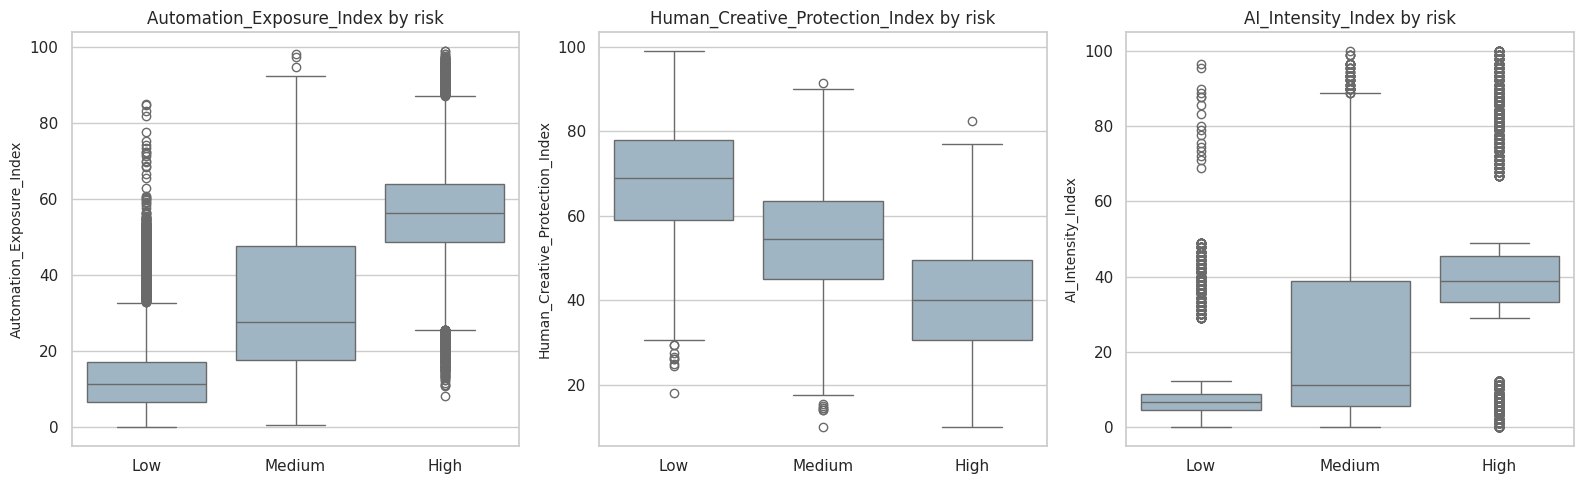

PosixPath('analysis_outputs/figures/engineered_indices_by_risk.png')

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
index_cols = [
    "Automation_Exposure_Index",
    "Human_Creative_Protection_Index",
    "AI_Intensity_Index",
]
for ax, col in zip(axes, index_cols):
    sns.boxplot(data=df_fe, x=TARGET_COL, y=col, order=RISK_ORDER, ax=ax, color="#9ab6c9")
    ax.set_title(f"{col} by risk")
    ax.set_xlabel("")
savefig("engineered_indices_by_risk.png")

## 8. 统计检验

类别变量使用卡方检验并计算 Cramer's V；数值变量使用 Kruskal-Wallis 检验，避免对正态性做强假设；相关性分析使用 Spearman 相关。

In [16]:
def cramers_v(table: pd.DataFrame) -> float:
    chi2, _, _, _ = chi2_contingency(table)
    n = table.to_numpy().sum()
    if n == 0:
        return np.nan
    r, k = table.shape
    return math.sqrt((chi2 / n) / max(1, min(k - 1, r - 1)))

chi_square_results = []
for col in CATEGORICAL_COLS:
    contingency = pd.crosstab(df_fe[col], df_fe[TARGET_COL])
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    chi_square_results.append(
        {
            "feature": col,
            "chi2": chi2,
            "dof": dof,
            "p_value": p_value,
            "cramers_v": cramers_v(contingency),
        }
    )

chi_square_df = pd.DataFrame(chi_square_results).sort_values("cramers_v", ascending=False)
display(chi_square_df)
chi_square_df.to_csv(TABLE_DIR / "chi_square_tests.csv", index=False)

kruskal_results = []
numeric_test_cols = NUMERIC_COLS + [
    "Automation_Exposure_Index",
    "Human_Creative_Protection_Index",
    "AI_Intensity_Index",
]
for col in numeric_test_cols:
    groups = [group[col].dropna().to_numpy() for _, group in df_fe.groupby(TARGET_COL, observed=True)]
    h_stat, p_value = kruskal(*groups)
    n = len(df_fe[col].dropna())
    k = len(groups)
    epsilon_sq = max(0, (h_stat - k + 1) / max(1, n - k))
    kruskal_results.append(
        {
            "feature": col,
            "h_stat": h_stat,
            "p_value": p_value,
            "epsilon_squared": epsilon_sq,
        }
    )

kruskal_df = pd.DataFrame(kruskal_results).sort_values("epsilon_squared", ascending=False)
display(kruskal_df)
kruskal_df.to_csv(TABLE_DIR / "kruskal_tests.csv", index=False)

,feature,chi2,dof,p_value,cramers_v
5,AI_Adoption_Level,"7,935.675",4,0.000,0.445
4,Job_Level,"1,642.963",4,0.000,0.203
2,Job_Role,"1,235.216",46,0.000,0.176
1,Industry,"1,153.409",14,0.000,0.170
0,Education_Level,599.421,6,0.000,0.122
3,Company_Size,7.878,4,0.096,0.014


,feature,h_stat,p_value,epsilon_squared
2,Routine_Task_Percentage,"12,206.010",0.000,0.610
7,Tasks_Automated_Percentage,"11,710.359",0.000,0.586
9,Automation_Exposure_Index,"11,558.609",0.000,0.578
3,Creativity_Requirement,"11,537.334",0.000,0.577
10,Human_Creative_Protection_Index,"9,175.125",0.000,0.459
11,AI_Intensity_Index,"6,207.093",0.000,0.310
6,AI_Usage_Hours_Per_Week,"6,021.071",0.000,0.301
5,Number_of_AI_Tools_Used,"5,622.493",0.000,0.281
8,AI_Training_Hours,"4,937.879",0.000,0.247
4,Human_Interaction_Level,513.489,0.000,0.026


,spearman_with_risk
Layoff_Risk_Score,1.000
Routine_Task_Percentage,0.781
Tasks_Automated_Percentage,0.765
Automation_Exposure_Index,0.760
AI_Adoption_Score,0.622
AI_Intensity_Index,0.556
AI_Usage_Hours_Per_Week,0.547
Number_of_AI_Tools_Used,0.529
AI_Training_Hours,0.496
Age,-0.037


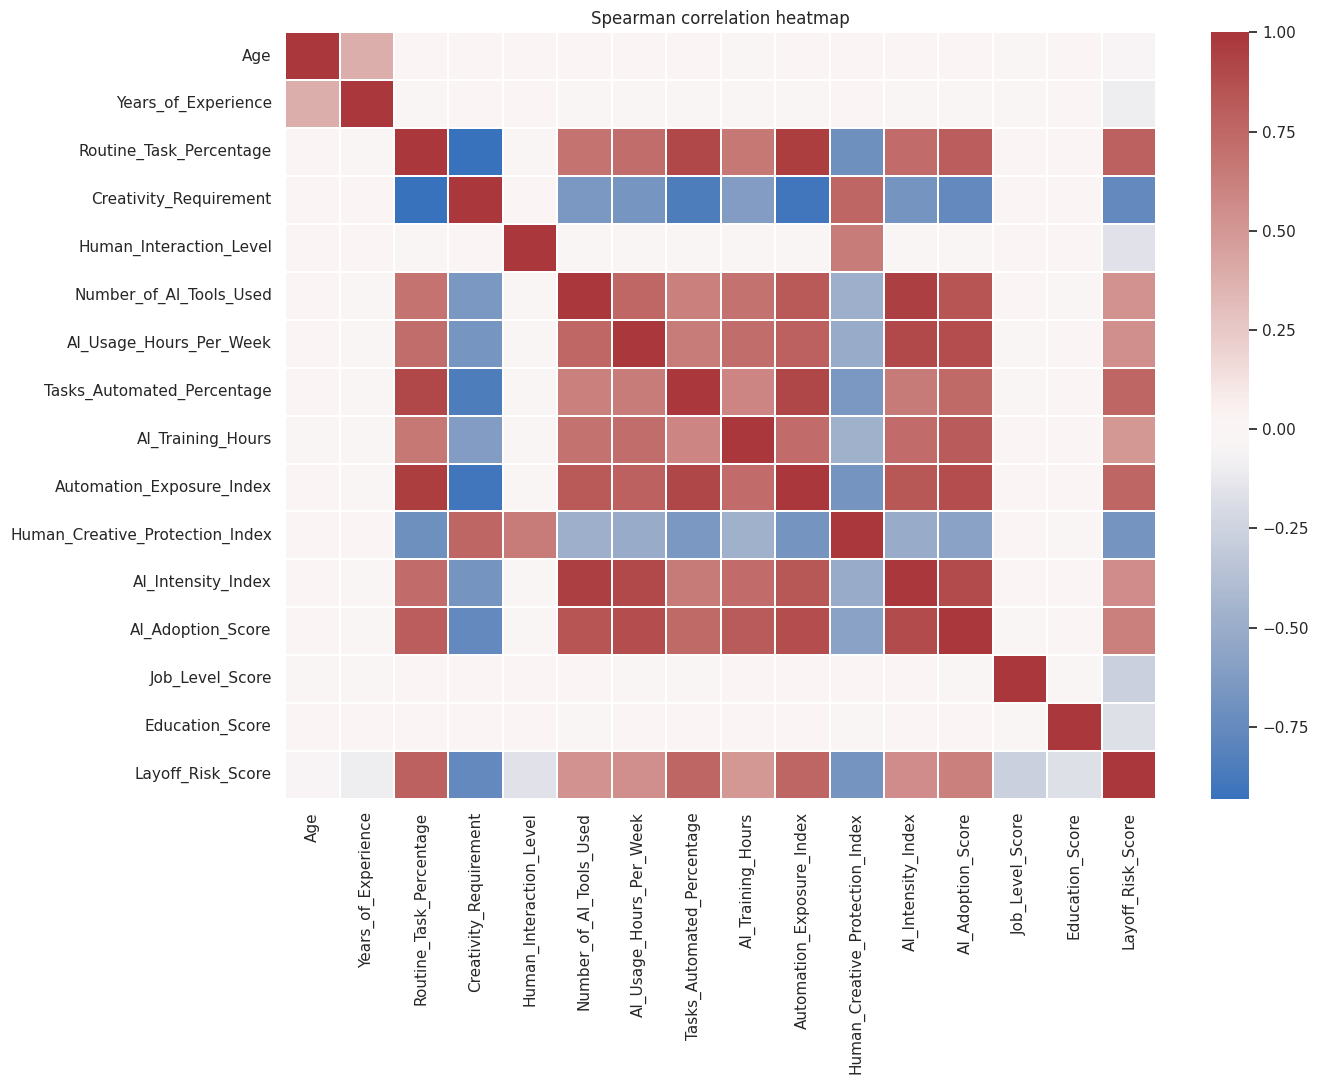

PosixPath('analysis_outputs/figures/spearman_correlation_heatmap.png')

In [17]:
corr_cols = NUMERIC_COLS + [
    "Automation_Exposure_Index",
    "Human_Creative_Protection_Index",
    "AI_Intensity_Index",
    "AI_Adoption_Score",
    "Job_Level_Score",
    "Education_Score",
    "Layoff_Risk_Score",
]
spearman_corr = df_fe[corr_cols].corr(method="spearman")
display(spearman_corr["Layoff_Risk_Score"].sort_values(ascending=False).to_frame("spearman_with_risk"))
spearman_corr.to_csv(TABLE_DIR / "spearman_correlation.csv")

plt.figure(figsize=(14, 11))
sns.heatmap(spearman_corr, cmap="vlag", center=0, linewidths=0.2)
plt.title("Spearman correlation heatmap")
savefig("spearman_correlation_heatmap.png")

## 9. 多分类预测建模

目标：预测 `Layoff_Risk = Low / Medium / High`。

模型：Logistic Regression、Decision Tree、Random Forest、Gradient Boosting。

数据划分：70% 训练集、30% 测试集，使用分层抽样保持目标类别比例。

In [18]:
model_df = df_fe.copy()
drop_for_multiclass = [TARGET_COL, "Risk_Binary", "Layoff_Risk_Score"]
X = model_df.drop(columns=drop_for_multiclass)
y = model_df[TARGET_COL].astype(str)

categorical_features = [
    "Education_Level",
    "Industry",
    "Job_Role",
    "Company_Size",
    "Job_Level",
    "AI_Adoption_Level",
    "Experience_Band",
    "Age_Band",
]
categorical_features = [c for c in categorical_features if c in X.columns]
numeric_features = [c for c in X.columns if c not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]
            ),
            categorical_features,
        ),
    ],
    remainder="drop",
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

multiclass_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=250,
        max_depth=14,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

fitted_multiclass = {}
model_metrics = []
model_reports = {}

for name, estimator in multiclass_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", estimator)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    fitted_multiclass[name] = pipe
    model_metrics.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test, y_pred),
            "macro_f1": f1_score(y_test, y_pred, average="macro"),
            "weighted_f1": f1_score(y_test, y_pred, average="weighted"),
        }
    )
    model_reports[name] = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

model_metrics_df = pd.DataFrame(model_metrics).sort_values("macro_f1", ascending=False)
display(model_metrics_df)
model_metrics_df.to_csv(TABLE_DIR / "multiclass_model_metrics.csv", index=False)

best_multiclass_name = model_metrics_df.iloc[0]["model"]
best_multiclass_model = fitted_multiclass[best_multiclass_name]
print(f"最佳多分类模型: {best_multiclass_name}")
print(classification_report(y_test, best_multiclass_model.predict(X_test), zero_division=0))

,model,accuracy,macro_f1,weighted_f1
0,Logistic Regression,0.961,0.961,0.961
3,Gradient Boosting,0.914,0.914,0.914
2,Random Forest,0.890,0.890,0.890
1,Decision Tree,0.817,0.818,0.819


最佳多分类模型: Logistic Regression
              precision    recall  f1-score   support

        High       0.97      0.97      0.97      2039
         Low       0.97      0.97      0.97      1981
      Medium       0.94      0.94      0.94      1980

    accuracy                           0.96      6000
   macro avg       0.96      0.96      0.96      6000
weighted avg       0.96      0.96      0.96      6000



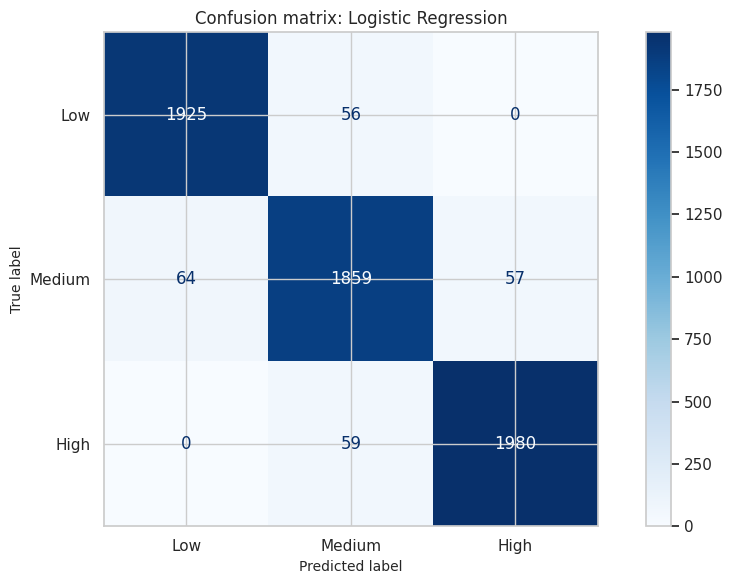

PosixPath('analysis_outputs/figures/multiclass_confusion_matrix.png')

In [19]:
best_y_pred = best_multiclass_model.predict(X_test)
cm = confusion_matrix(y_test, best_y_pred, labels=RISK_ORDER)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=RISK_ORDER)
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion matrix: {best_multiclass_name}")
savefig("multiclass_confusion_matrix.png")

## 10. 二分类高风险预警模型

目标：预测是否为 `High` 风险。此处重点关注 `High` 类别召回率，避免漏报高风险样本。

In [20]:
X_bin = model_df.drop(columns=[TARGET_COL, "Risk_Binary", "Layoff_Risk_Score"])
y_bin = model_df["Risk_Binary"].map({"Not_High": 0, "High": 1}).astype(int)

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_bin,
    y_bin,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_bin,
)

binary_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=250,
        max_depth=14,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

fitted_binary = {}
binary_metrics = []

for name, estimator in binary_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", estimator)])
    pipe.fit(X_train_bin, y_train_bin)
    y_pred = pipe.predict(X_test_bin)
    y_proba = pipe.predict_proba(X_test_bin)[:, 1]
    fitted_binary[name] = pipe
    binary_metrics.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test_bin, y_pred),
            "high_precision": precision_score(y_test_bin, y_pred, zero_division=0),
            "high_recall": recall_score(y_test_bin, y_pred, zero_division=0),
            "high_f1": f1_score(y_test_bin, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test_bin, y_proba),
            "pr_auc": average_precision_score(y_test_bin, y_proba),
        }
    )

binary_metrics_df = pd.DataFrame(binary_metrics).sort_values(
    ["high_recall", "high_f1", "pr_auc"], ascending=False
)
display(binary_metrics_df)
binary_metrics_df.to_csv(TABLE_DIR / "binary_model_metrics.csv", index=False)

best_binary_name = binary_metrics_df.iloc[0]["model"]
best_binary_model = fitted_binary[best_binary_name]
y_proba_best = best_binary_model.predict_proba(X_test_bin)[:, 1]
print(f"最佳高风险预警模型: {best_binary_name}")
print(classification_report(y_test_bin, best_binary_model.predict(X_test_bin), target_names=["Not_High", "High"]))

,model,accuracy,high_precision,high_recall,high_f1,roc_auc,pr_auc
0,Logistic Regression,0.980,0.961,0.982,0.971,0.998,0.997
1,Random Forest,0.938,0.882,0.943,0.912,0.988,0.978
2,Gradient Boosting,0.963,0.954,0.935,0.945,0.994,0.990


最佳高风险预警模型: Logistic Regression
              precision    recall  f1-score   support

    Not_High       0.99      0.98      0.99      3961
        High       0.96      0.98      0.97      2039

    accuracy                           0.98      6000
   macro avg       0.98      0.98      0.98      6000
weighted avg       0.98      0.98      0.98      6000



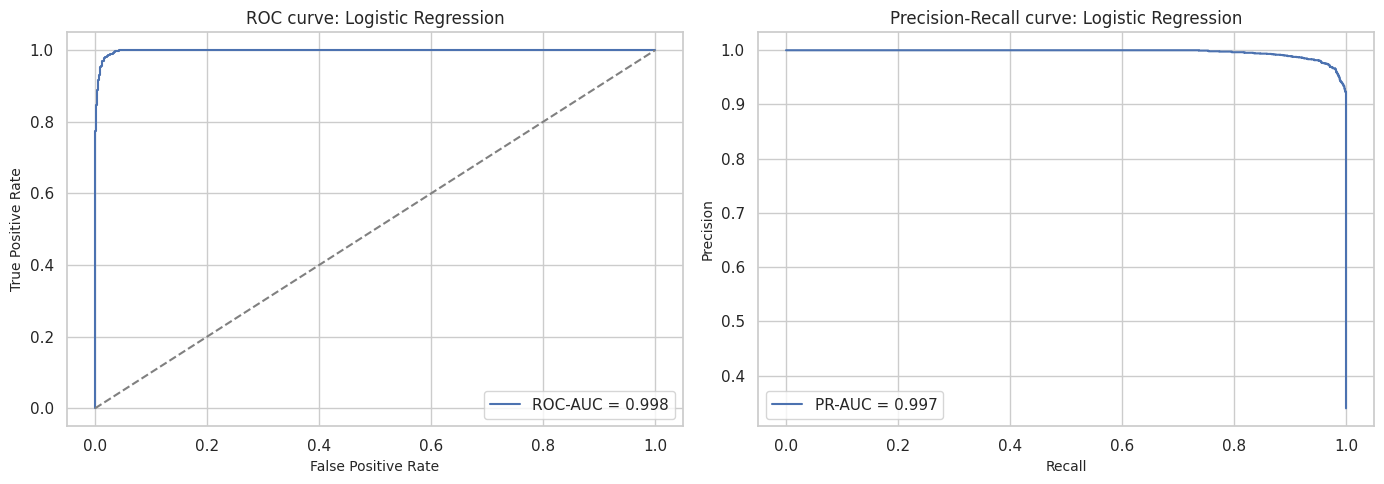

,selected_threshold,precision,recall,f1
0,0.872,0.989,0.901,0.943


              precision    recall  f1-score   support

    Not_High       0.95      0.99      0.97      3961
        High       0.99      0.90      0.94      2039

    accuracy                           0.96      6000
   macro avg       0.97      0.95      0.96      6000
weighted avg       0.96      0.96      0.96      6000



In [21]:
fpr, tpr, roc_thresholds = roc_curve(y_test_bin, y_proba_best)
precision, recall, pr_thresholds = precision_recall_curve(y_test_bin, y_proba_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test_bin, y_proba_best):.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title(f"ROC curve: {best_binary_name}")
axes[0].legend()

axes[1].plot(recall, precision, label=f"PR-AUC = {average_precision_score(y_test_bin, y_proba_best):.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title(f"Precision-Recall curve: {best_binary_name}")
axes[1].legend()
savefig("binary_roc_pr_curves.png")

threshold_table = pd.DataFrame(
    {
        "threshold": np.r_[pr_thresholds, np.nan],
        "precision": precision,
        "recall": recall,
    }
).dropna()
recall_target = 0.90
eligible_thresholds = threshold_table[threshold_table["recall"] >= recall_target]
selected_threshold = (
    eligible_thresholds.sort_values("precision", ascending=False).iloc[0]["threshold"]
    if len(eligible_thresholds) > 0
    else 0.50
)
tuned_pred = (y_proba_best >= selected_threshold).astype(int)

tuned_summary = {
    "selected_threshold": selected_threshold,
    "precision": precision_score(y_test_bin, tuned_pred, zero_division=0),
    "recall": recall_score(y_test_bin, tuned_pred, zero_division=0),
    "f1": f1_score(y_test_bin, tuned_pred, zero_division=0),
}
display(pd.DataFrame([tuned_summary]))
print(classification_report(y_test_bin, tuned_pred, target_names=["Not_High", "High"]))

## 11. 模型解释

先使用 permutation importance 解释原始输入特征对最佳多分类模型的影响；再根据模型类型补充系数或树模型特征重要性。若环境安装了 `shap`，可在本节最后运行可选 SHAP 分析。

,feature,importance_mean,importance_std
0,Routine_Task_Percentage,0.211,0.004
1,Tasks_Automated_Percentage,0.192,0.002
2,Job_Level_Score,0.186,0.003
3,Industry,0.130,0.004
4,Education_Score,0.099,0.003
5,Human_Creative_Protection_Index,0.080,0.003
6,Automation_Exposure_Index,0.077,0.003
7,Creativity_Requirement,0.074,0.003
8,Experience_Band,0.036,0.001
9,Job_Level,0.033,0.002


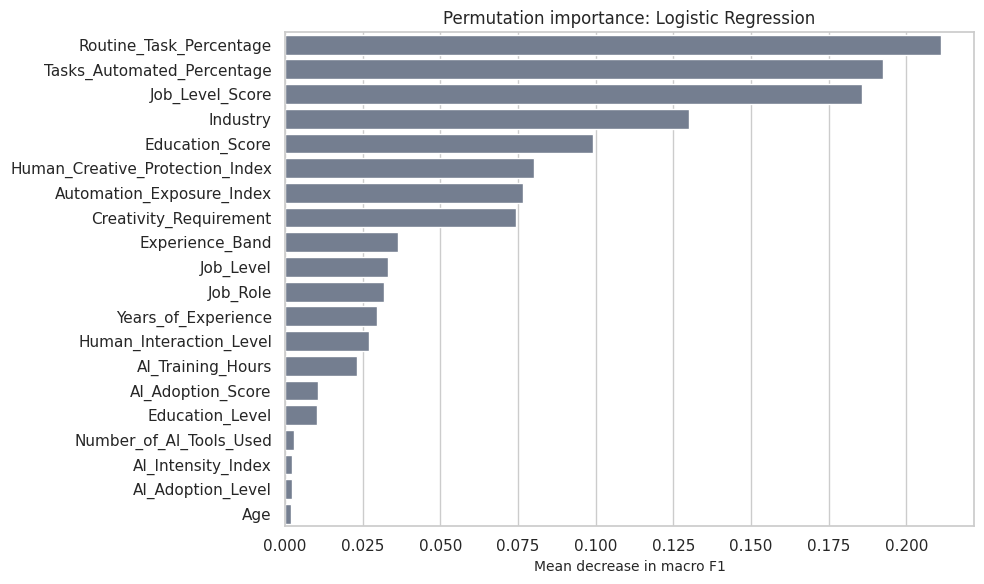

PosixPath('analysis_outputs/figures/permutation_importance_multiclass.png')

In [22]:
perm = permutation_importance(
    best_multiclass_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="f1_macro",
    n_jobs=-1,
)

permutation_importance_df = (
    pd.DataFrame(
        {
            "feature": X_test.columns,
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)
display(permutation_importance_df.head(20))
permutation_importance_df.to_csv(TABLE_DIR / "permutation_importance_multiclass.csv", index=False)

sns.barplot(
    data=permutation_importance_df.head(20),
    y="feature",
    x="importance_mean",
    color="#6f7d95",
)
plt.title(f"Permutation importance: {best_multiclass_name}")
plt.xlabel("Mean decrease in macro F1")
plt.ylabel("")
savefig("permutation_importance_multiclass.png")

,feature,mean_abs_coefficient
0,Industry_Education,3.664
1,Job_Level_Score,3.252
2,Routine_Task_Percentage,3.227
3,Tasks_Automated_Percentage,3.148
4,Industry_Manufacturing,3.046
5,Industry_Healthcare,2.977
6,Industry_Retail,2.274
7,Education_Score,1.971
8,Job_Level_Senior,1.815
9,Experience_Band_15+,1.684


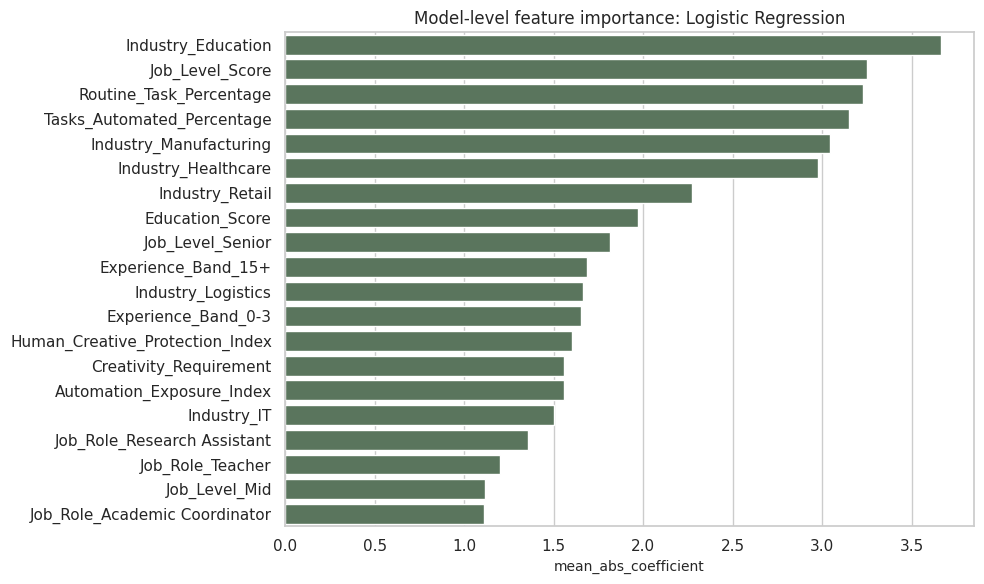

PosixPath('analysis_outputs/figures/model_feature_importance_multiclass.png')

In [23]:
transformed_feature_names = best_multiclass_model.named_steps["preprocessor"].get_feature_names_out()
clean_feature_names = [
    name.replace("num__", "").replace("cat__", "")
    for name in transformed_feature_names
]
model_core = best_multiclass_model.named_steps["model"]

if hasattr(model_core, "coef_"):
    model_importance_values = np.mean(np.abs(model_core.coef_), axis=0)
    model_importance_type = "mean_abs_coefficient"
elif hasattr(model_core, "feature_importances_"):
    model_importance_values = model_core.feature_importances_
    model_importance_type = "tree_feature_importance"
else:
    model_importance_values = np.zeros(len(clean_feature_names))
    model_importance_type = "not_available"

model_feature_importance_df = (
    pd.DataFrame(
        {
            "feature": clean_feature_names,
            model_importance_type: model_importance_values,
        }
    )
    .sort_values(model_importance_type, ascending=False)
    .reset_index(drop=True)
)

display(model_feature_importance_df.head(25))
model_feature_importance_df.to_csv(TABLE_DIR / "model_feature_importance_multiclass.csv", index=False)

sns.barplot(
    data=model_feature_importance_df.head(20),
    y="feature",
    x=model_importance_type,
    color="#557a5a",
)
plt.title(f"Model-level feature importance: {best_multiclass_name}")
plt.xlabel(model_importance_type)
plt.ylabel("")
savefig("model_feature_importance_multiclass.png")

In [24]:
try:
    import shap

    shap_available = True
except Exception as exc:
    shap_available = False
    print(f"SHAP 未安装或不可用，已跳过 SHAP 分析: {exc}")

if shap_available:
    sample = X_test.sample(min(1000, len(X_test)), random_state=RANDOM_STATE)
    transformed_sample = best_multiclass_model.named_steps["preprocessor"].transform(sample)
    explainer = shap.Explainer(best_multiclass_model.named_steps["model"], transformed_sample)
    shap_values = explainer(transformed_sample)
    shap.summary_plot(shap_values, transformed_sample, feature_names=clean_feature_names, show=False)
    savefig("shap_summary_optional.png")

SHAP 未安装或不可用，已跳过 SHAP 分析: No module named 'shap'


## 12. 聚类与人群分层

在不使用 `Layoff_Risk` 的情况下，根据岗位任务、AI 使用、自动化、经验和岗位级别进行无监督分群，再观察每个群体的风险分布。

In [25]:
cluster_features = [
    "Routine_Task_Percentage",
    "Creativity_Requirement",
    "Human_Interaction_Level",
    "AI_Adoption_Score",
    "Number_of_AI_Tools_Used",
    "AI_Usage_Hours_Per_Week",
    "Tasks_Automated_Percentage",
    "AI_Training_Hours",
    "Years_of_Experience",
    "Job_Level_Score",
    "Automation_Exposure_Index",
    "Human_Creative_Protection_Index",
    "AI_Intensity_Index",
]

cluster_matrix = df_fe[cluster_features].copy()
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_matrix)

silhouette_rows = []
for k in range(2, 7):
    labels = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit_predict(cluster_scaled)
    score = silhouette_score(
        cluster_scaled,
        labels,
        sample_size=min(5000, len(df_fe)),
        random_state=RANDOM_STATE,
    )
    silhouette_rows.append({"k": k, "silhouette_score": score})

silhouette_df = pd.DataFrame(silhouette_rows)
display(silhouette_df)
silhouette_df.to_csv(TABLE_DIR / "kmeans_silhouette_scores.csv", index=False)

selected_k = int(silhouette_df.sort_values("silhouette_score", ascending=False).iloc[0]["k"])
kmeans = KMeans(n_clusters=selected_k, n_init=30, random_state=RANDOM_STATE)
df_fe["Cluster"] = kmeans.fit_predict(cluster_scaled)
print(f"选择聚类数: {selected_k}")

cluster_profile = (
    df_fe.groupby("Cluster")
    .agg(
        n=(TARGET_COL, "size"),
        high_rate=("Risk_Binary", lambda s: (s == "High").mean()),
        avg_automation_exposure=("Automation_Exposure_Index", "mean"),
        avg_protection=("Human_Creative_Protection_Index", "mean"),
        avg_ai_intensity=("AI_Intensity_Index", "mean"),
        avg_routine=("Routine_Task_Percentage", "mean"),
        avg_tasks_automated=("Tasks_Automated_Percentage", "mean"),
        avg_creativity=("Creativity_Requirement", "mean"),
        avg_interaction=("Human_Interaction_Level", "mean"),
        avg_experience=("Years_of_Experience", "mean"),
    )
    .sort_values("high_rate", ascending=False)
)
display(cluster_profile)
cluster_profile.to_csv(TABLE_DIR / "cluster_profile.csv")

,k,silhouette_score
0,2,0.390
1,3,0.376
2,4,0.257
3,5,0.199
4,6,0.192


选择聚类数: 2


,n,high_rate,avg_automation_exposure,avg_protection,avg_ai_intensity,avg_routine,avg_tasks_automated,avg_creativity,avg_interaction,avg_experience
Cluster,,,,,,,,,,
0,9307,0.628,57.043,43.099,45.682,73.005,52.657,26.666,59.531,7.234
1,10693,0.089,15.343,63.340,6.608,33.504,23.801,66.170,60.511,7.293


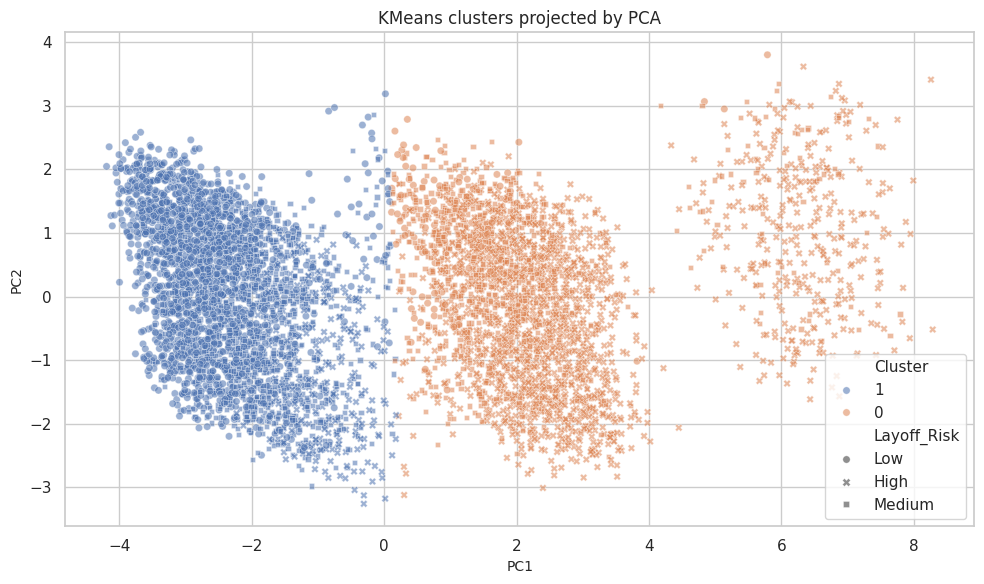

Layoff_Risk,Low,Medium,High
Cluster,,,
0,0.062,0.310,0.628
1,0.563,0.348,0.089


In [26]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
cluster_pca = pca.fit_transform(cluster_scaled)
pca_df = pd.DataFrame(cluster_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = df_fe["Cluster"].astype(str).to_numpy()
pca_df[TARGET_COL] = df_fe[TARGET_COL].astype(str).to_numpy()

sample_pca = pca_df.sample(min(6000, len(pca_df)), random_state=RANDOM_STATE)
sns.scatterplot(
    data=sample_pca,
    x="PC1",
    y="PC2",
    hue="Cluster",
    style=TARGET_COL,
    alpha=0.55,
    s=28,
)
plt.title("KMeans clusters projected by PCA")
savefig("cluster_pca_scatter.png")

cluster_risk_distribution = pd.crosstab(
    df_fe["Cluster"], df_fe[TARGET_COL], normalize="index"
).reindex(columns=RISK_ORDER)
display(cluster_risk_distribution)
cluster_risk_distribution.to_csv(TABLE_DIR / "cluster_risk_distribution.csv")

In [27]:
cluster_descriptions = []
global_high_rate = df_fe["Risk_Binary"].eq("High").mean()
global_exposure = df_fe["Automation_Exposure_Index"].mean()
global_protection = df_fe["Human_Creative_Protection_Index"].mean()
global_ai_intensity = df_fe["AI_Intensity_Index"].mean()

for cluster_id, row in cluster_profile.iterrows():
    label_parts = []
    if row["high_rate"] >= global_high_rate + 0.10:
        label_parts.append("高风险")
    elif row["high_rate"] <= global_high_rate - 0.10:
        label_parts.append("低风险")
    else:
        label_parts.append("中等风险")

    if row["avg_automation_exposure"] >= global_exposure + 8:
        label_parts.append("高自动化暴露")
    elif row["avg_automation_exposure"] <= global_exposure - 8:
        label_parts.append("低自动化暴露")

    if row["avg_protection"] >= global_protection + 8:
        label_parts.append("高创造力互动保护")
    elif row["avg_protection"] <= global_protection - 8:
        label_parts.append("低创造力互动保护")

    if row["avg_ai_intensity"] >= global_ai_intensity + 8:
        label_parts.append("高 AI 使用强度")
    elif row["avg_ai_intensity"] <= global_ai_intensity - 8:
        label_parts.append("低 AI 使用强度")

    top_industries = (
        df_fe[df_fe["Cluster"] == cluster_id]["Industry"]
        .value_counts(normalize=True)
        .head(3)
        .mul(100)
        .round(1)
    )
    top_roles = (
        df_fe[df_fe["Cluster"] == cluster_id]["Job_Role"]
        .value_counts(normalize=True)
        .head(3)
        .mul(100)
        .round(1)
    )

    cluster_descriptions.append(
        {
            "Cluster": cluster_id,
            "profile_label": "、".join(label_parts),
            "n": int(row["n"]),
            "high_rate": row["high_rate"],
            "top_industries": "; ".join([f"{idx}: {val:.1f}%" for idx, val in top_industries.items()]),
            "top_roles": "; ".join([f"{idx}: {val:.1f}%" for idx, val in top_roles.items()]),
        }
    )

cluster_descriptions_df = pd.DataFrame(cluster_descriptions).sort_values("high_rate", ascending=False)
display(cluster_descriptions_df)
cluster_descriptions_df.to_csv(TABLE_DIR / "cluster_descriptions.csv", index=False)

,Cluster,profile_label,n,high_rate,top_industries,top_roles
0,0,高风险、高自动化暴露、低创造力互动保护、高 AI 使用强度,9307,0.628,Finance: 12.8%; Manufacturing: 12.8%; Healthca...,Operator: 4.6%; Medical Assistant: 4.5%; Accou...
1,1,低风险、低自动化暴露、高创造力互动保护、低 AI 使用强度,10693,0.089,Telecom: 13.3%; Healthcare: 12.9%; Retail: 12.9%,Nurse: 4.7%; Financial Analyst: 4.5%; Network ...


## 13. 业务洞察与建议

以下结论由前述统计分析、建模和聚类结果自动汇总。由于该数据集是观察型数据，相关性和模型重要性不能直接解释为严格因果关系。

In [28]:
top_industries = high_risk_by_industry.head(3)
top_roles = high_risk_by_role.head(5)
ai_risk = risk_distribution(df, "AI_Adoption_Level").reindex(["High", "Medium", "Low"])
job_level_risk = risk_distribution(df, "Job_Level").reindex(["Entry", "Mid", "Senior"])
education_risk = risk_distribution(df, "Education_Level")

high_means = df.groupby(TARGET_COL)[NUMERIC_COLS].mean().reindex(RISK_ORDER)
best_multiclass_row = model_metrics_df.iloc[0]
best_binary_row = binary_metrics_df.iloc[0]
top_perm = permutation_importance_df.head(8)["feature"].tolist()
most_risky_cluster = cluster_profile.index[0]

print("核心结论")
print("=" * 60)
print(
    "1. 高风险行业集中在: "
    + ", ".join([f"{idx}({row['High_Rate']:.1%})" for idx, row in top_industries.iterrows()])
)
print(
    "2. 高风险岗位集中在: "
    + ", ".join([f"{idx}({row['High_Rate']:.1%})" for idx, row in top_roles.iterrows()])
)
print(
    "3. AI 采用等级越高，高风险比例越高: "
    + ", ".join([f"{idx}={row['High_Rate']:.1%}" for idx, row in ai_risk.iterrows()])
)
print(
    "4. 岗位级别具有明显缓冲作用: "
    + ", ".join([f"{idx}={row['High_Rate']:.1%}" for idx, row in job_level_risk.iterrows()])
)
print(
    "5. 高风险样本的重复性任务比例、自动化比例和 AI 使用强度显著更高；创造力要求显著更低。"
)
print(
    f"   High 风险均值: Routine={high_means.loc['High','Routine_Task_Percentage']:.1f}, "
    f"Automated={high_means.loc['High','Tasks_Automated_Percentage']:.1f}, "
    f"Creativity={high_means.loc['High','Creativity_Requirement']:.1f}"
)
print(
    f"   Low 风险均值: Routine={high_means.loc['Low','Routine_Task_Percentage']:.1f}, "
    f"Automated={high_means.loc['Low','Tasks_Automated_Percentage']:.1f}, "
    f"Creativity={high_means.loc['Low','Creativity_Requirement']:.1f}"
)
print(
    "6. AI 培训小时数在高风险组更高，这更像是高风险岗位接受更多培训或补救投入；不能单凭本数据断言培训本身提高风险。"
)
print(
    f"7. 最佳多分类模型为 {best_multiclass_row['model']}，"
    f"Macro F1={best_multiclass_row['macro_f1']:.3f}，Accuracy={best_multiclass_row['accuracy']:.3f}。"
)
print(
    f"8. 最佳二分类预警模型为 {best_binary_row['model']}，"
    f"High Recall={best_binary_row['high_recall']:.3f}，PR-AUC={best_binary_row['pr_auc']:.3f}。"
)
print("9. 对模型最重要的输入特征包括: " + ", ".join(top_perm))
print(
    f"10. 聚类中最高风险群体为 Cluster {most_risky_cluster}，"
    f"高风险比例 {cluster_profile.loc[most_risky_cluster, 'high_rate']:.1%}。"
)

核心结论
1. 高风险行业集中在: Manufacturing(48.2%), Logistics(41.5%), Retail(40.7%)
2. 高风险岗位集中在: Operator(50.2%), Production Supervisor(48.3%), Quality Engineer(46.0%), Inventory Analyst(44.6%), Dispatcher(42.1%)
3. AI 采用等级越高，高风险比例越高: High=80.8%, Medium=58.2%, Low=9.2%
4. 岗位级别具有明显缓冲作用: Entry=44.5%, Mid=30.7%, Senior=11.5%
5. 高风险样本的重复性任务比例、自动化比例和 AI 使用强度显著更高；创造力要求显著更低。
   High 风险均值: Routine=75.2, Automated=56.0, Creativity=23.8
   Low 风险均值: Routine=28.5, Automated=19.5, Creativity=71.9
6. AI 培训小时数在高风险组更高，这更像是高风险岗位接受更多培训或补救投入；不能单凭本数据断言培训本身提高风险。
7. 最佳多分类模型为 Logistic Regression，Macro F1=0.961，Accuracy=0.961。
8. 最佳二分类预警模型为 Logistic Regression，High Recall=0.982，PR-AUC=0.997。
9. 对模型最重要的输入特征包括: Routine_Task_Percentage, Tasks_Automated_Percentage, Job_Level_Score, Industry, Education_Score, Human_Creative_Protection_Index, Automation_Exposure_Index, Creativity_Requirement
10. 聚类中最高风险群体为 Cluster 0，高风险比例 62.8%。


### 可操作建议

1. **优先预警对象**：制造、物流、零售等高风险行业中的重复性任务占比高、自动化比例高、AI 采用等级高的岗位，应优先进入风险监测名单。
2. **岗位转型方向**：对 `Operator`、`Production Supervisor`、`Quality Engineer`、`Inventory Analyst` 等高风险岗位，优先推动流程管理、异常处理、跨职能协作、数据解释和 AI 协同能力训练。
3. **培训策略**：AI 培训不应只作为高风险后的补救措施，应与岗位重设计结合，重点降低纯重复任务占比，提高员工对 AI 输出的判断、复核和业务决策能力。
4. **组织层面**：公司规模与风险的统计关联较弱，说明风险更可能来自岗位任务结构、AI 采用水平和岗位级别，而不是单纯来自组织规模。
5. **模型应用**：二分类高风险预警模型表现较好，可用于内部筛查，但落地时应引入人工复核、业务规则和近期组织变动信息，避免把模型分数直接作为裁员决策依据。